load the dataset

In [ ]:
# Step 1: Load the dataset
import pandas as pd

# Replace with the actual path to your file
data_path = "/content/synthetic_10000.csv"

# Load the dataset
df = pd.read_csv(data_path)

# Show basic info
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n")
print(df.info())

Shape of dataset: (10000, 32)

First 5 rows:
    id  radius_mean  texture_mean  perimeter_mean    area_mean  \
0   1     8.387907     16.612219       52.739775   211.806855   
1   2    12.168740     22.720099       77.909185   475.755432   
2   3    18.697717     15.351773      121.499142  1099.001160   
3   4    11.901168     16.465606       75.200041   423.099479   
4   5    14.783549     16.255440       94.770108   646.469011   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0         0.117365          0.062582        0.013984             0.013814   
1         0.072444          0.072620        0.053483             0.016846   
2         0.092354          0.119766        0.126737             0.081216   
3         0.087774          0.034319        0.011766             0.016278   
4         0.086316          0.060573        0.058796             0.015516   

   symmetry_mean  ...  texture_worst  perimeter_worst   area_worst  \
0       0.187023  ...      18.

preprocessing

In [ ]:
# Step 2: Check duplicates

# 2a) Full-row duplicates
print("Initial shape:", df.shape)
dup_count = df.duplicated().sum()
print("Full-row duplicates found:", dup_count)

if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Dropped full-row duplicates. New shape:", df.shape)
else:
    print("No full-row duplicates.")

# 2b) Duplicate IDs (only if an 'id' column exists)
id_cols = [c for c in df.columns if c.lower() == "id"]
if id_cols:
    id_col = id_cols[0]
    dup_id = df[id_col].duplicated().sum()
    print(f"Duplicate values in '{id_col}':", dup_id)
    # If you want to de-duplicate IDs now, uncomment the next two lines:
    # if dup_id > 0:
    #     df = df[~df[id_col].duplicated(keep="first")].reset_index(drop=True)
else:
    print("No 'id' column detected.")


Initial shape: (10000, 32)
Full-row duplicates found: 0
No full-row duplicates.
Duplicate values in 'id': 0


In [ ]:
print("Missing Values :\n",df.isnull().sum())


Missing Values :
 id                         0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
diagnosis                  0
dtype: int64


In [ ]:
# Cell: Drop 'id' (if present) + map 'diagnosis' to 0/1 + save cleaned file
import pandas as pd

print("Starting shape:", df.shape)

# 1) Drop 'id' column if present
if 'id' in df.columns:
    df = df.drop(columns=['id']).reset_index(drop=True)
    print("Dropped 'id' column.")
else:
    print("No 'id' column found; nothing dropped.")

# 2) Show current diagnosis unique values
print("Unique diagnosis values (before):", sorted(df['diagnosis'].astype(str).unique()))

# 3) Mapping (robust)
map_dict = {
    'B': 0, 'b': 0, 'benign': 0, 'Benign': 0,
    'M': 1, 'm': 1, 'malignant': 1, 'Malignant': 1,
    '0': 0, '1': 1
}
# apply mapping after stripping whitespace
df['diagnosis'] = df['diagnosis'].astype(str).str.strip().map(lambda x: map_dict.get(x, x))

# 4) Convert to numeric (coerce any unmapped values to NaN so we can detect them)
df['diagnosis'] = pd.to_numeric(df['diagnosis'], errors='coerce')

# 5) Check for any unmapped values
if df['diagnosis'].isna().any():
    print("ERROR: Some diagnosis values could not be mapped. See unique unmapped values below (they appear as NaN after conversion).")
    print(df.loc[df['diagnosis'].isna(), 'diagnosis'].head(20))
    # show their original raw values for debugging
    raw_unmapped = df.loc[df['diagnosis'].isna()].copy()
    raw_unmapped['raw_value'] = raw_unmapped['diagnosis'].astype(str)  # placeholder; originally strings were overwritten
    print("If you see unmapped values, paste here a sample of the raw 'diagnosis' cells and I'll update mapping.")
else:
    # 6) finalize and save
    df['diagnosis'] = df['diagnosis'].astype(int)
    print("Mapping successful.")
    print("Unique diagnosis values (after):", sorted(df['diagnosis'].unique()))
    print("\nClass counts:\n", df['diagnosis'].value_counts())
    print("\nClass proportions:\n", df['diagnosis'].value_counts(normalize=True).round(3))
    # save cleaned file
    out = "breast_cancer_cleaned_step.csv"
    df.to_csv(out, index=False)
    print(f"\nSaved cleaned dataset to: {out}")


Starting shape: (10000, 32)
Dropped 'id' column.
Unique diagnosis values (before): ['B', 'M']
Mapping successful.
Unique diagnosis values (after): [np.int64(0), np.int64(1)]

Class counts:
 diagnosis
0    6274
1    3726
Name: count, dtype: int64

Class proportions:
 diagnosis
0    0.627
1    0.373
Name: proportion, dtype: float64

Saved cleaned dataset to: breast_cancer_cleaned_step.csv


EDA


Summary statistics:

        radius_mean  texture_mean  perimeter_mean     area_mean  \
count  10000.000000  10000.000000    10000.000000  10000.000000   
mean      14.115704     19.283722       91.880959    653.221216   
std        3.494770      4.299944       24.116961    348.336754   
min        3.376784      5.081421       18.991070      0.000000   
25%       11.765361     16.354969       75.648080    427.398981   
50%       13.379936     18.980506       86.531485    553.850284   
75%       15.845470     21.944320      103.735872    777.913822   
max       31.335033     39.280000      212.621616   2802.642622   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count     10000.000000      10000.000000    10000.000000         10000.000000   
mean          0.096336          0.103943        0.088404             0.048749   
std           0.014024          0.052493        0.078040             0.038299   
min           0.046710          0.000000        0.

/tmp/ipython-input-2684855378.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="diagnosis", data=df, palette="Set2")


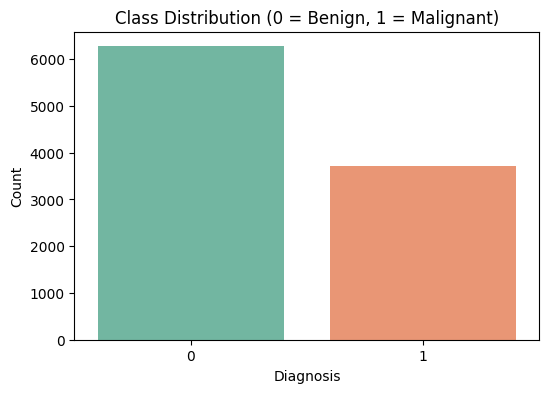

In [ ]:
# Step 4a: Summary statistics
print("\nSummary statistics:\n")
print(df.describe())

# Step 4b: Plot class distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="diagnosis", data=df, palette="Set2")
plt.title("Class Distribution (0 = Benign, 1 = Malignant)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()


detailed EDA

Top 12 features used for detailed EDA:
concave points_worst    0.791404
perimeter_worst         0.780179
radius_worst            0.773705
concave points_mean     0.771192
perimeter_mean          0.738654
area_worst              0.729144
radius_mean             0.726098
area_mean               0.702983
concavity_mean          0.697457
concavity_worst         0.670239
compactness_worst       0.593514
compactness_mean        0.593265
Name: diagnosis, dtype: float64

Skewness and kurtosis (top12):
                      skewness  kurtosis
area_worst              1.6810    2.8551
area_mean               1.5389    2.9294
concavity_mean          1.3213    1.5290
compactness_worst       1.2274    1.8255
concave points_mean     1.1884    1.1931
compactness_mean        1.0926    1.2974
perimeter_worst         1.0843    0.8895
radius_worst            1.0562    0.7503
concavity_worst         0.9944    0.7646
perimeter_mean          0.9567    0.9716
radius_mean             0.9060    0.8472
concave p

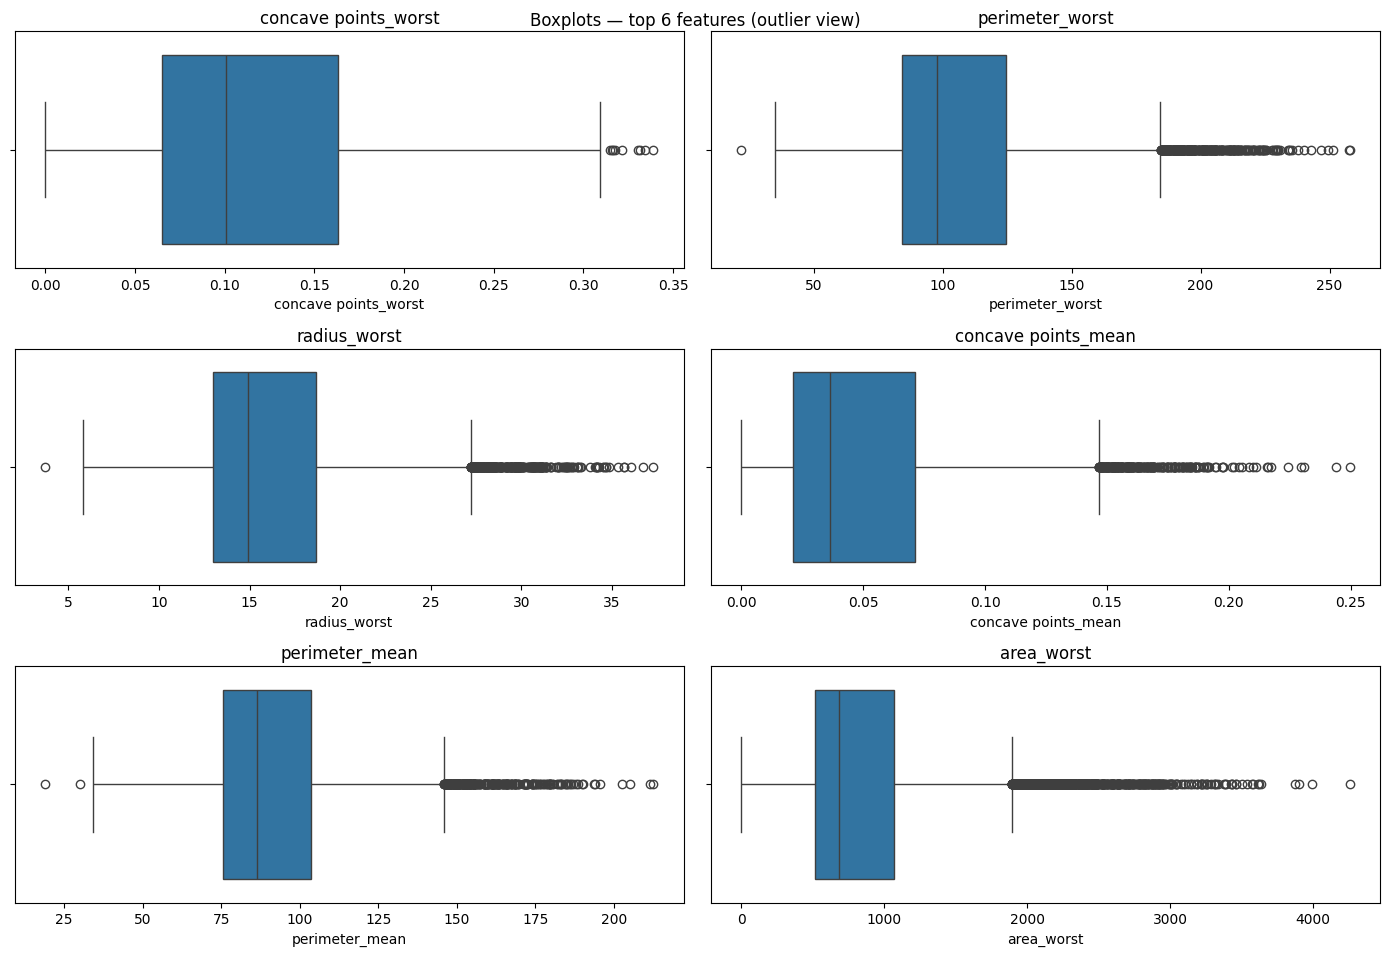

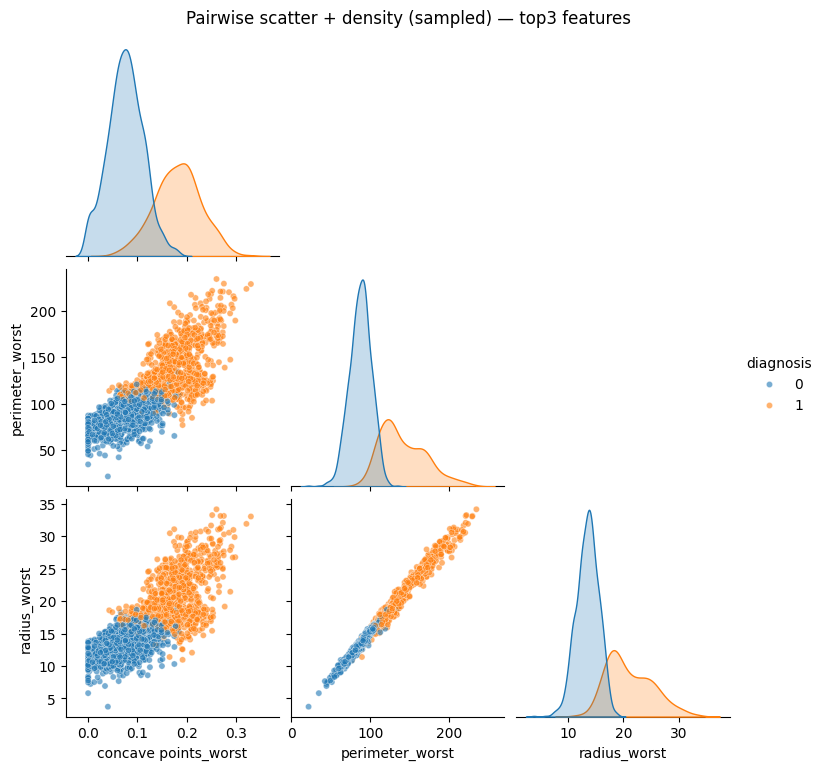


VIF (top12 features):
                 feature       VIF
4         perimeter_mean  3005.685
6            radius_mean  2920.970
2           radius_worst   405.138
1        perimeter_worst   219.456
7              area_mean   205.516
5             area_worst   168.642
8         concavity_mean    37.916
3    concave points_mean    35.586
11      compactness_mean    24.059
9        concavity_worst    23.627
0   concave points_worst    17.140
10     compactness_worst    14.566

Saved outputs to: /content/outputs


In [ ]:
# Cell: Detailed EDA — skewness/kurtosis, boxplots (top6), pairwise scatter (top3), VIF (top12)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

OUT = Path("outputs")
OUT.mkdir(exist_ok=True)

# Ensure 'top12' is computed else compute from scratch
target = "diagnosis"
if "top12" not in globals():
    corr = df.corr()
    top12 = corr[target].abs().drop(labels=[target]).sort_values(ascending=False).head(12)
else:
    # if top12 exists as a Series, keep; if it's a DataFrame from previous cell, rebuild
    try:
        top12 = top12
    except Exception:
        corr = df.corr()
        top12 = corr[target].abs().drop(labels=[target]).sort_values(ascending=False).head(12)

top12_feats = list(top12.index)
top6_feats = top12_feats[:6]
top3_feats = top12_feats[:3]

print("Top 12 features used for detailed EDA:")
print(top12)

# 1) Skewness & Kurtosis
skew_kurt = pd.DataFrame({
    "skewness": df[top12_feats].skew().round(4),
    "kurtosis": df[top12_feats].kurtosis().round(4)
}).sort_values("skewness", key=abs, ascending=False)
print("\nSkewness and kurtosis (top12):")
print(skew_kurt)

# Save skew/kurt table
skew_kurt.to_csv(OUT / "top12_skew_kurt.csv")

# 2) Boxplots for top6 (to inspect outliers)
plt.figure(figsize=(14, 10))
for i, col in enumerate(top6_feats, 1):
    plt.subplot(3,2,i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.suptitle("Boxplots — top 6 features (outlier view)", y=0.95)
plt.tight_layout()
plt.savefig(OUT / "top6_boxplots.png", dpi=150)
plt.show()

# 3) Pairwise scatter + KDE for top3
sns.pairplot(df[top3_feats + [target]].sample(min(len(df), 2000), random_state=42),
             hue=target, corner=True, plot_kws={"alpha":0.6, "s":20})
plt.suptitle("Pairwise scatter + density (sampled) — top3 features", y=1.02)
plt.savefig(OUT / "top3_pairplot.png", dpi=150, bbox_inches='tight')
plt.show()

# 4) VIF for top12 to detect multicollinearity
# compute VIF using statsmodels if available, else use sklearn linear model fallback
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X_vif = df[top12_feats].assign(const=1)  # add constant to avoid division by zero
    vifs = []
    for i, col in enumerate(X_vif.columns[:-1]):  # skip const
        vif_val = variance_inflation_factor(X_vif.values, i)
        vifs.append((col, round(vif_val, 3)))
    vif_df = pd.DataFrame(vifs, columns=["feature","VIF"]).sort_values("VIF", ascending=False)
except Exception:
    # fallback: compute VIF via R^2 from sklearn linear regression
    from sklearn.linear_model import LinearRegression
    vif_list = []
    X = df[top12_feats].values
    for i in range(X.shape[1]):
        y_col = X[:, i]
        X_others = np.delete(X, i, axis=1)
        lr = LinearRegression().fit(X_others, y_col)
        r2 = lr.score(X_others, y_col)
        vif_val = 1.0 / (1.0 - r2) if (1 - r2) != 0 else np.inf
        vif_list.append((top12_feats[i], round(vif_val, 3)))
    vif_df = pd.DataFrame(vif_list, columns=["feature","VIF"]).sort_values("VIF", ascending=False)

print("\nVIF (top12 features):")
print(vif_df)
vif_df.to_csv(OUT / "top12_vif.csv", index=False)

print(f"\nSaved outputs to: {OUT.resolve()}")



--- Univariate Analysis: Histograms ---


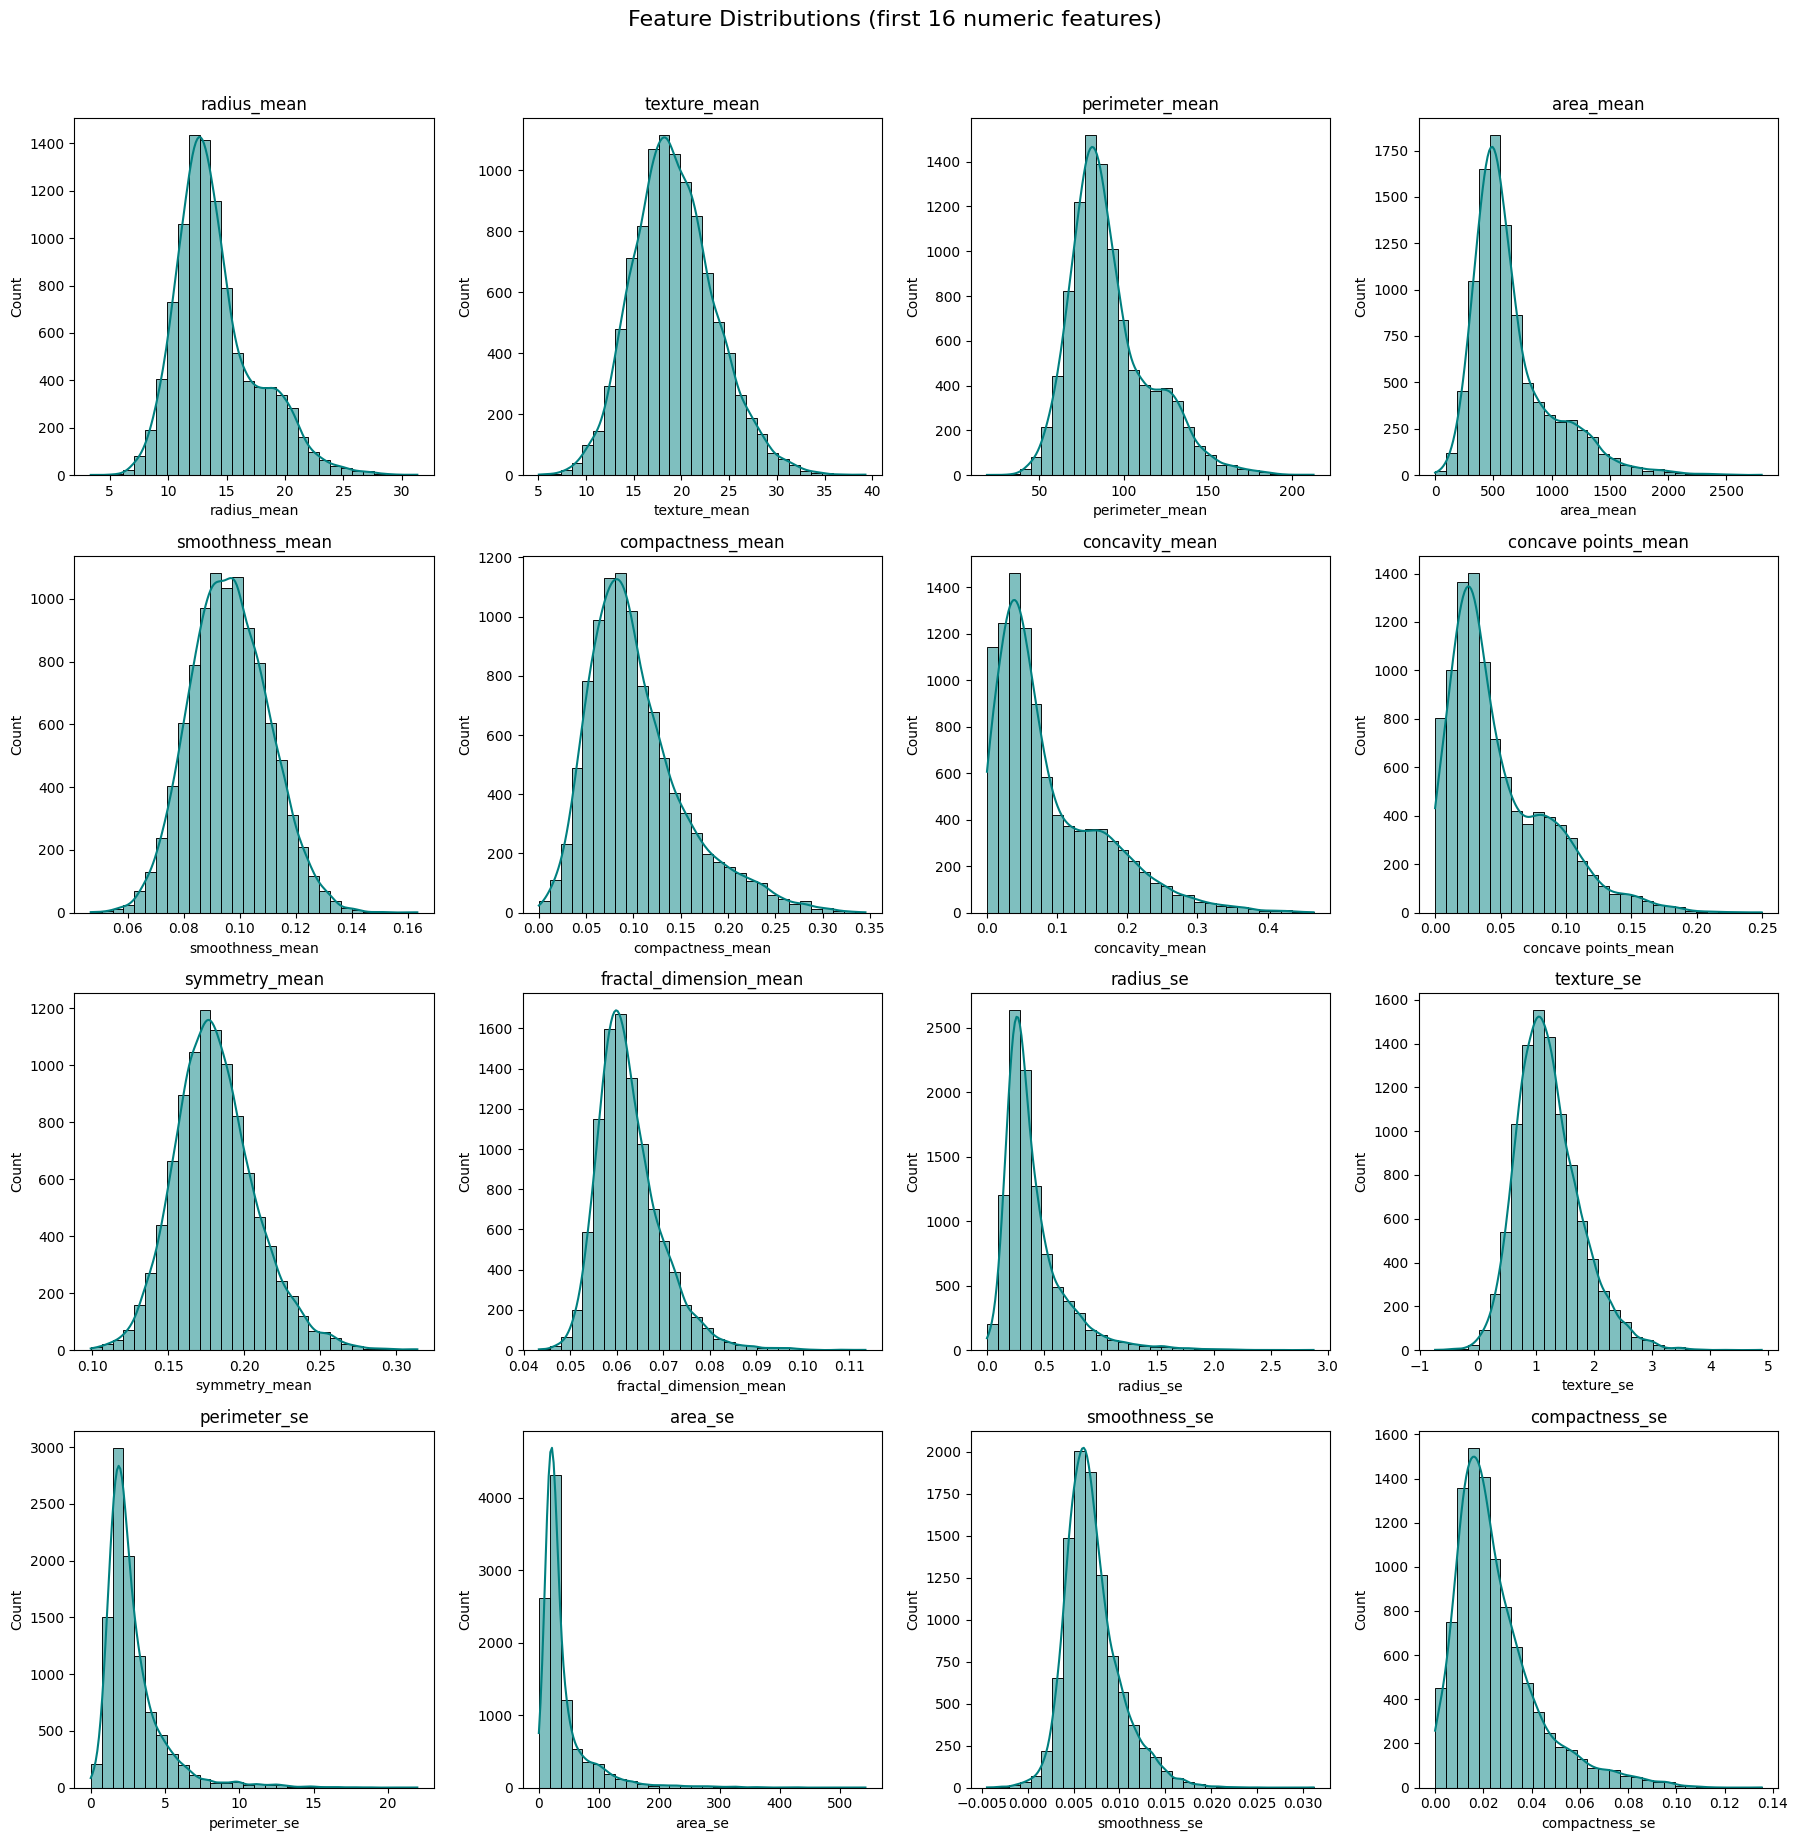


--- Correlation Heatmap ---


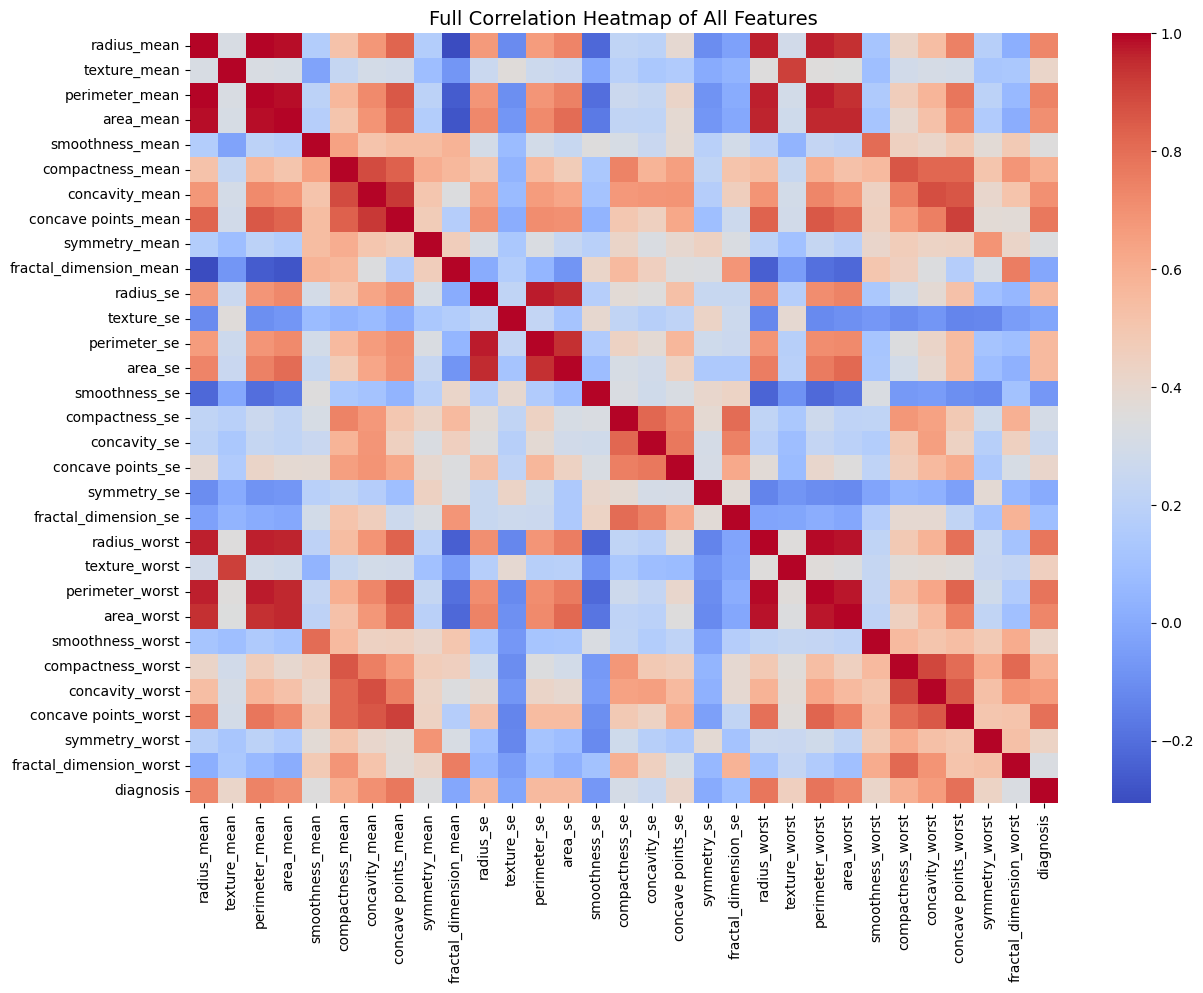


--- Outlier Detection using IQR ---
                      Outlier Count  Outlier %
area_mean                       631       6.31
area_se                        1153      11.53
area_worst                      799       7.99
compactness_mean                399       3.99
compactness_se                  510       5.10
compactness_worst               476       4.76
concave points_mean             250       2.50
concave points_se               253       2.53
concave points_worst              9       0.09
concavity_mean                  289       2.89


/tmp/ipython-input-2574405100.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outlier_summary.index[:10], y=outlier_summary['Outlier %'][:10], palette="crest")


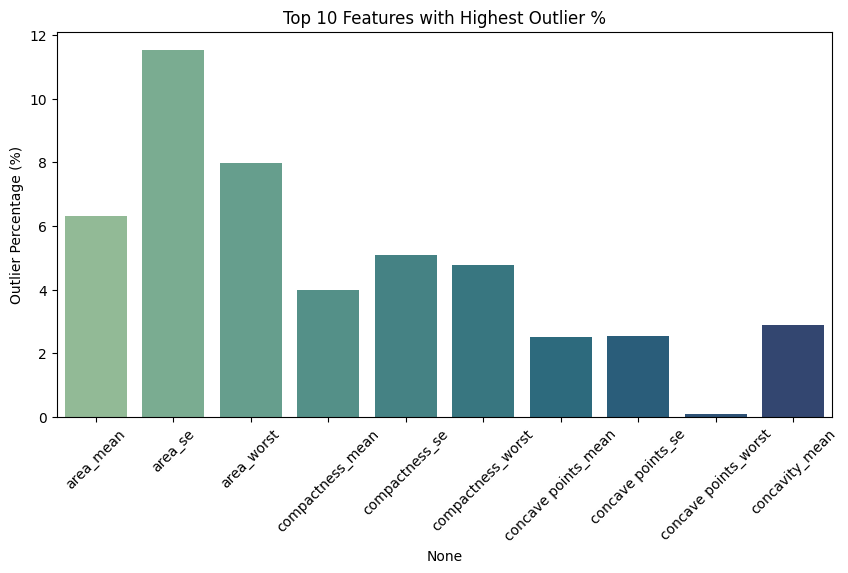


--- Feature Distribution by Class (Benign vs Malignant) ---


/tmp/ipython-input-2574405100.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=col, data=df, palette="Set2")
/tmp/ipython-input-2574405100.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=col, data=df, palette="Set2")
/tmp/ipython-input-2574405100.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=col, data=df, palette="Set2")


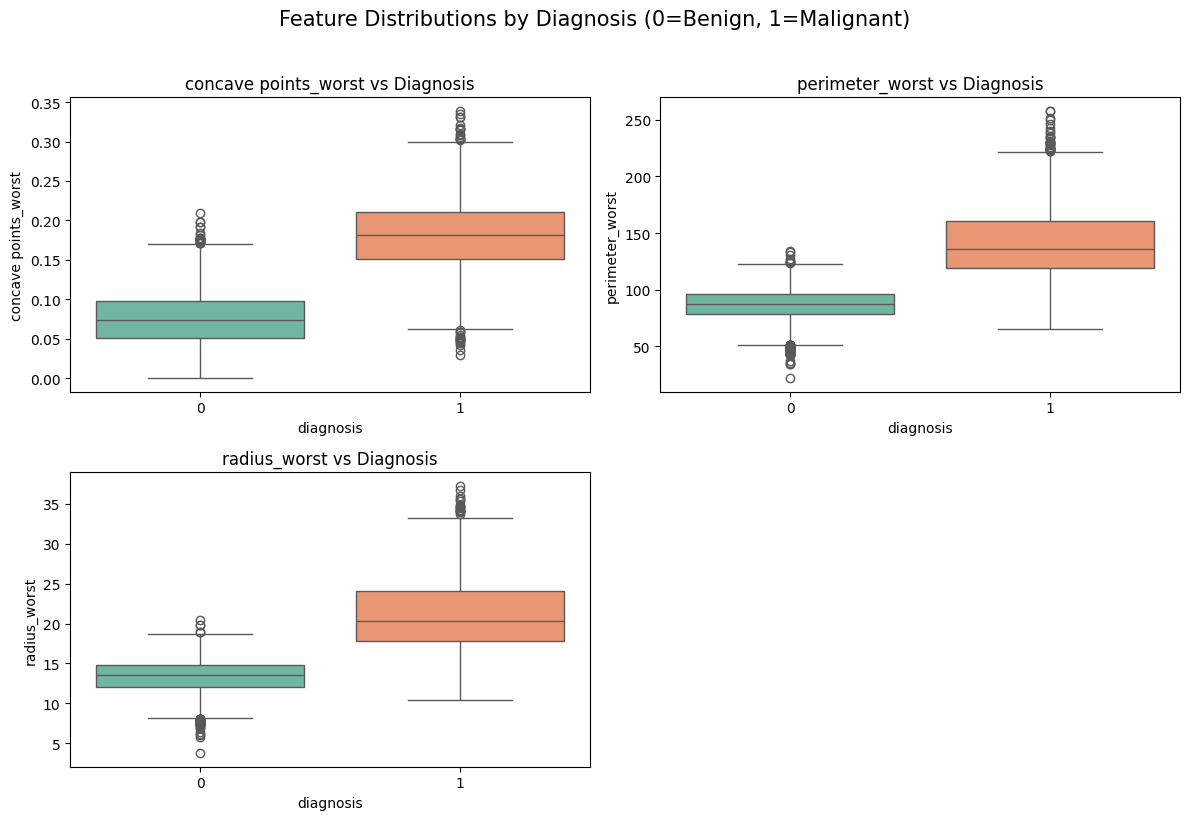


--- Missing Value Visualization ---


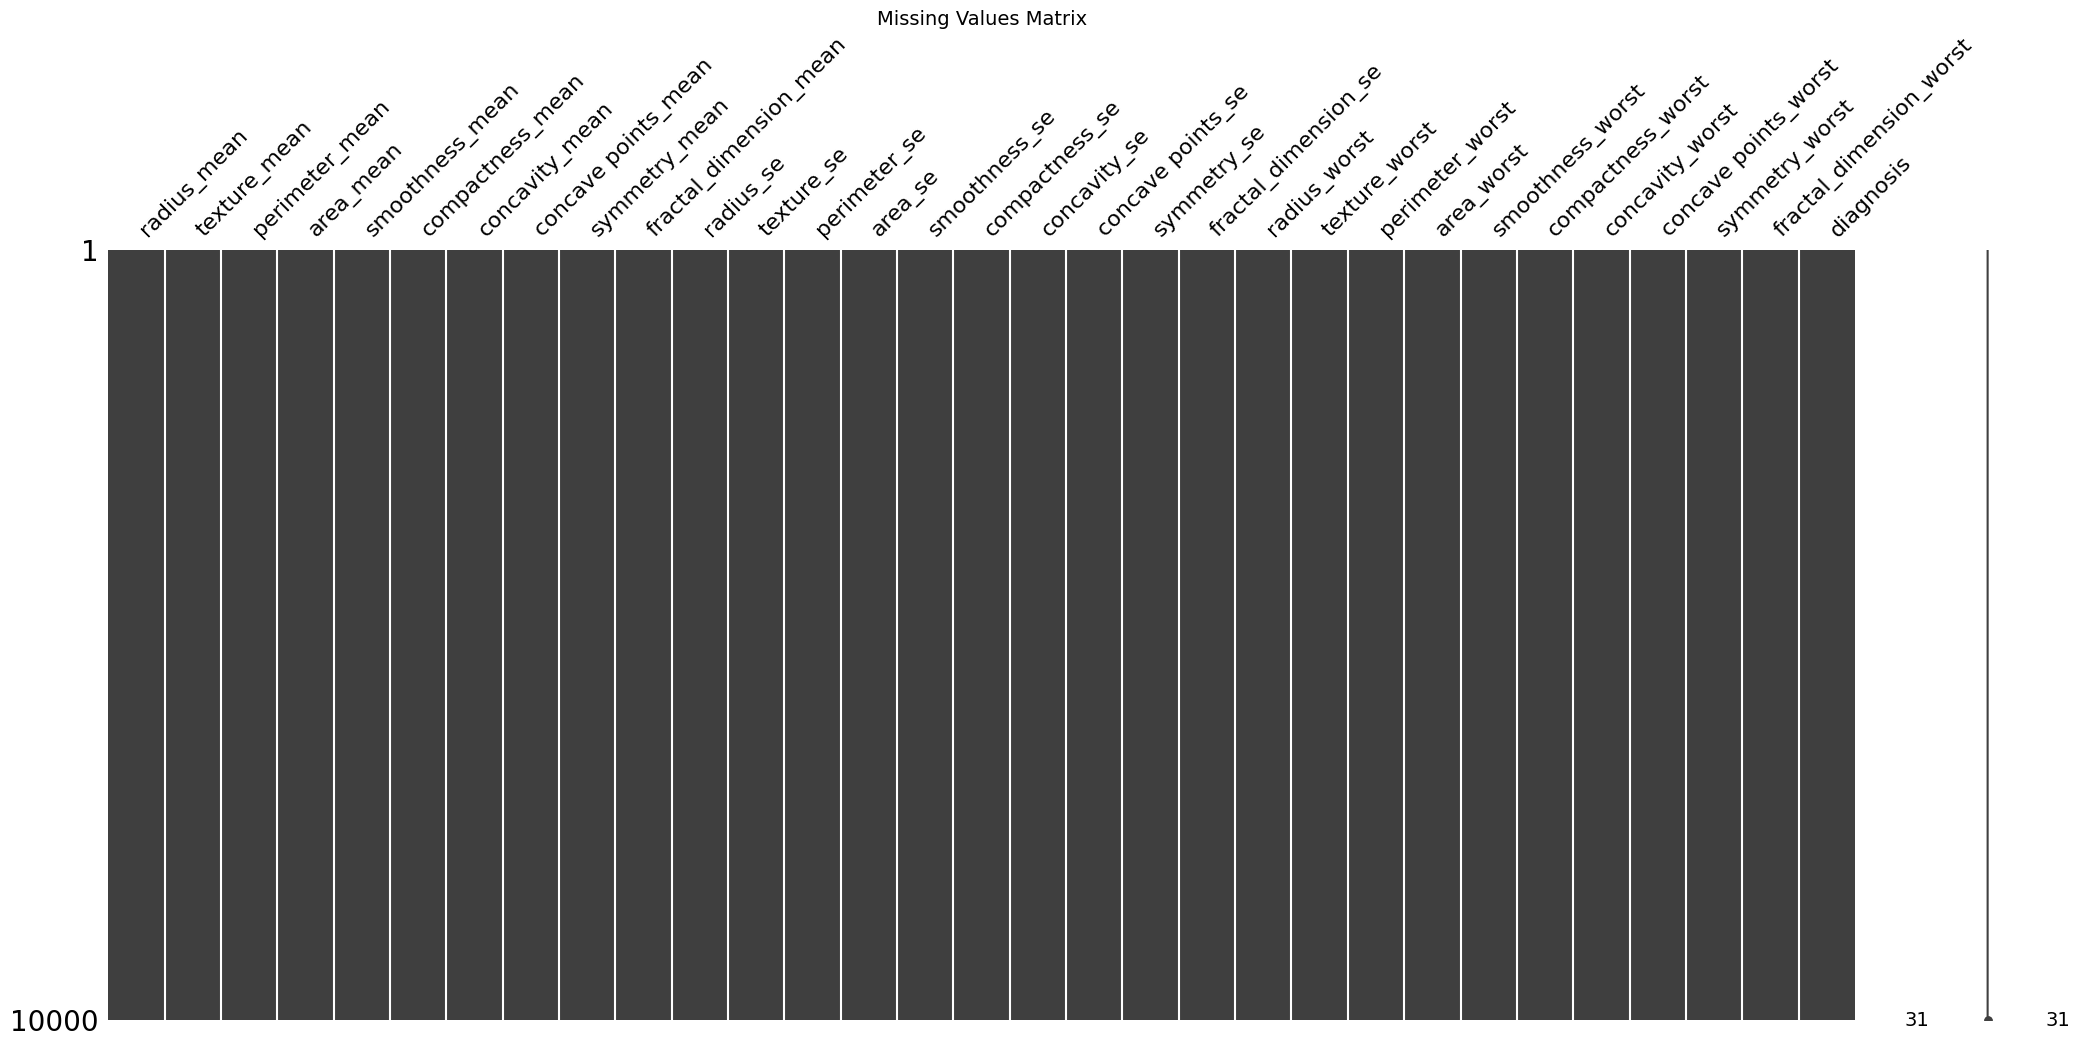


--- Normality Test (Shapiro-Wilk) ---
                       Distribution
radius_mean              Not Normal
texture_mean             Not Normal
perimeter_mean           Not Normal
area_mean                Not Normal
smoothness_mean              Normal
compactness_mean         Not Normal
concavity_mean           Not Normal
concave points_mean      Not Normal
symmetry_mean            Not Normal
fractal_dimension_mean   Not Normal


/tmp/ipython-input-2574405100.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='Set2')


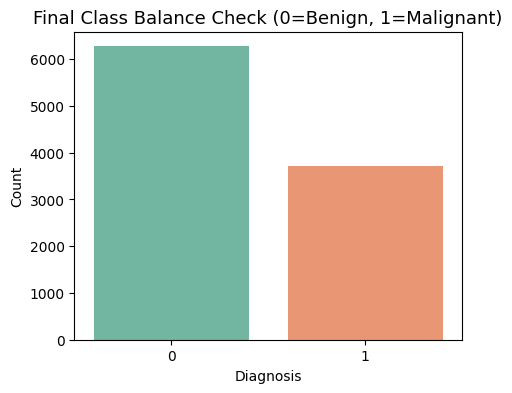

In [ ]:
# =====================================================
# 🔍 ADDITIONAL EDA STEPS — Complete Enhancement Section
# =====================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro

# =========================================
# 1️⃣ Univariate Analysis: Feature Distribution
# =========================================
print("\n--- Univariate Analysis: Histograms ---")
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(18, 18))
for i, col in enumerate(num_cols[:16], 1):  # first 16 features for clarity
    plt.subplot(4, 4, i)
    sns.histplot(df[col], kde=True, bins=30, color='teal')
    plt.title(col)
plt.suptitle("Feature Distributions (first 16 numeric features)", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# =========================================
# 2️⃣ Full Correlation Heatmap
# =========================================
print("\n--- Correlation Heatmap ---")
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Full Correlation Heatmap of All Features", fontsize=14)
plt.show()

# =========================================
# 3️⃣ Quantitative Outlier Detection using IQR
# =========================================
print("\n--- Outlier Detection using IQR ---")
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_count = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).sum()
outlier_percent = (outlier_count / len(df) * 100).sort_values(ascending=False)
outlier_summary = pd.DataFrame({'Outlier Count': outlier_count, 'Outlier %': outlier_percent.round(2)})
print(outlier_summary.head(10))  # top 10 features with most outliers

plt.figure(figsize=(10,5))
sns.barplot(x=outlier_summary.index[:10], y=outlier_summary['Outlier %'][:10], palette="crest")
plt.title("Top 10 Features with Highest Outlier %")
plt.ylabel("Outlier Percentage (%)")
plt.xticks(rotation=45)
plt.show()

# =========================================
# 4️⃣ Feature Distribution by Target Class
# =========================================
print("\n--- Feature Distribution by Class (Benign vs Malignant) ---")
selected_feats = df.corr()['diagnosis'].abs().sort_values(ascending=False).head(4).index.tolist()
plt.figure(figsize=(12, 8))
for i, col in enumerate(selected_feats[1:], 1):  # skip 'diagnosis'
    plt.subplot(2, 2, i)
    sns.boxplot(x='diagnosis', y=col, data=df, palette="Set2")
    plt.title(f"{col} vs Diagnosis")
plt.suptitle("Feature Distributions by Diagnosis (0=Benign, 1=Malignant)", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

# =========================================
# 5️⃣ Missing Value Visualization
# =========================================
print("\n--- Missing Value Visualization ---")
try:
    import missingno as msno
    msno.matrix(df)
    plt.title("Missing Values Matrix", fontsize=14)
    plt.show()
except ImportError:
    print("Install 'missingno' for missing value visualization (pip install missingno)")

# =========================================
# 6️⃣ Normality Test (Shapiro-Wilk)
# =========================================
print("\n--- Normality Test (Shapiro-Wilk) ---")
normality_results = {}
for col in num_cols[:10]:  # test only first 10 to save time
    stat, p = shapiro(df[col].sample(500) if len(df) > 500 else df[col])
    normality_results[col] = "Normal" if p > 0.05 else "Not Normal"
normality_df = pd.DataFrame.from_dict(normality_results, orient='index', columns=['Distribution'])
print(normality_df)

# =========================================
# 7️⃣ Class Balance Check (again for clarity)
# =========================================
plt.figure(figsize=(5,4))
sns.countplot(x='diagnosis', data=df, palette='Set2')
plt.title("Final Class Balance Check (0=Benign, 1=Malignant)", fontsize=13)
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()


Handle multicollinearity by dropping highly correlated features

In [ ]:
# Handle multicollinearity by dropping highly correlated features
import numpy as np
import pandas as pd

# Exclude target column
num_cols = [c for c in df.columns if c != "diagnosis"]

# Correlation matrix
corr = df[num_cols].corr().abs()

# Upper triangle mask
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Drop one feature from each highly correlated pair (corr > 0.9)
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

print(f"Features dropped due to high correlation: {to_drop}")

# Create new dataframe
df_reduced = df.drop(columns=to_drop)

print("Original shape:", df.shape)
print("Reduced shape:", df_reduced.shape)

# Save reduced dataset for next steps
df_reduced.to_csv("breast_cancer_reduced.csv", index=False)


Features dropped due to high correlation: ['perimeter_mean', 'area_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']
Original shape: (10000, 31)
Reduced shape: (10000, 21)


splittig the train and test data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load reduced dataset
df = pd.read_csv("breast_cancer_reduced.csv")

# Features and target
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (important for models like SVM, Logistic Regression, KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))


X_train shape: (8000, 20)
X_test shape: (2000, 20)
y_train distribution:
 diagnosis
0    0.627375
1    0.372625
Name: proportion, dtype: float64


model implementation

In [ ]:
# Import required libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True, random_state=42)
}

# Train and evaluate models
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else "N/A"
    })

# Create DataFrame for comparison
results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
print(results_df)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:03:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2              XGBoost    0.9855   0.982480  0.978523  0.980498  0.999006
4                  SVM    0.9855   0.987738  0.973154  0.980392  0.998795
1        Random Forest    0.9800   0.976996  0.969128  0.973046  0.998531
3                  KNN    0.9770   0.988811  0.948993  0.968493  0.989610
0  Logistic Regression    0.9755   0.974114  0.959732  0.966870  0.997311


In [ ]:
# ⚙️ Hybrid Model: XGBoost + SVM + Meta Logistic Regression

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Define base models
xgb = XGBClassifier(eval_metric="logloss", random_state=42)
svm = SVC(probability=True, random_state=42)

# Define meta-model
meta_model = LogisticRegression(max_iter=1000, random_state=42)

# Build hybrid stacking classifier
hybrid_model = StackingClassifier(
    estimators=[("xgb", xgb), ("svm", svm)],
    final_estimator=meta_model,
    stack_method='predict_proba',
    passthrough=True,   # include original features + base predictions
    n_jobs=-1
)

# Train the hybrid model
hybrid_model.fit(X_train, y_train)

# Predict
y_pred = hybrid_model.predict(X_test)
y_proba = hybrid_model.predict_proba(X_test)[:, 1]

# Evaluate performance
hybrid_results = {
    "Model": "Hybrid (XGBoost + SVM)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

# Show hybrid model performance
print("\n🔹 Hybrid Model Performance 🔹")
for k, v in hybrid_results.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

# Compare with previous models (if available)
try:
    comparison_df = pd.concat([results_df, pd.DataFrame([hybrid_results])], ignore_index=True)
    print("\n\n=== Combined Model Comparison ===")
    print(comparison_df.sort_values(by="F1 Score", ascending=False))
except:
    print("\nOnly hybrid model available (no previous results to compare).")



🔹 Hybrid Model Performance 🔹
Model: Hybrid (XGBoost + SVM)
Accuracy: 0.9860
Precision: 0.9891
Recall: 0.9732
F1 Score: 0.9811
ROC-AUC: 0.9989


=== Combined Model Comparison ===
                    Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
5  Hybrid (XGBoost + SVM)    0.9860   0.989086  0.973154  0.981055  0.998939
0                 XGBoost    0.9855   0.982480  0.978523  0.980498  0.999006
1                     SVM    0.9855   0.987738  0.973154  0.980392  0.998795
2           Random Forest    0.9800   0.976996  0.969128  0.973046  0.998531
3                     KNN    0.9770   0.988811  0.948993  0.968493  0.989610
4     Logistic Regression    0.9755   0.974114  0.959732  0.966870  0.997311


confusion matrix

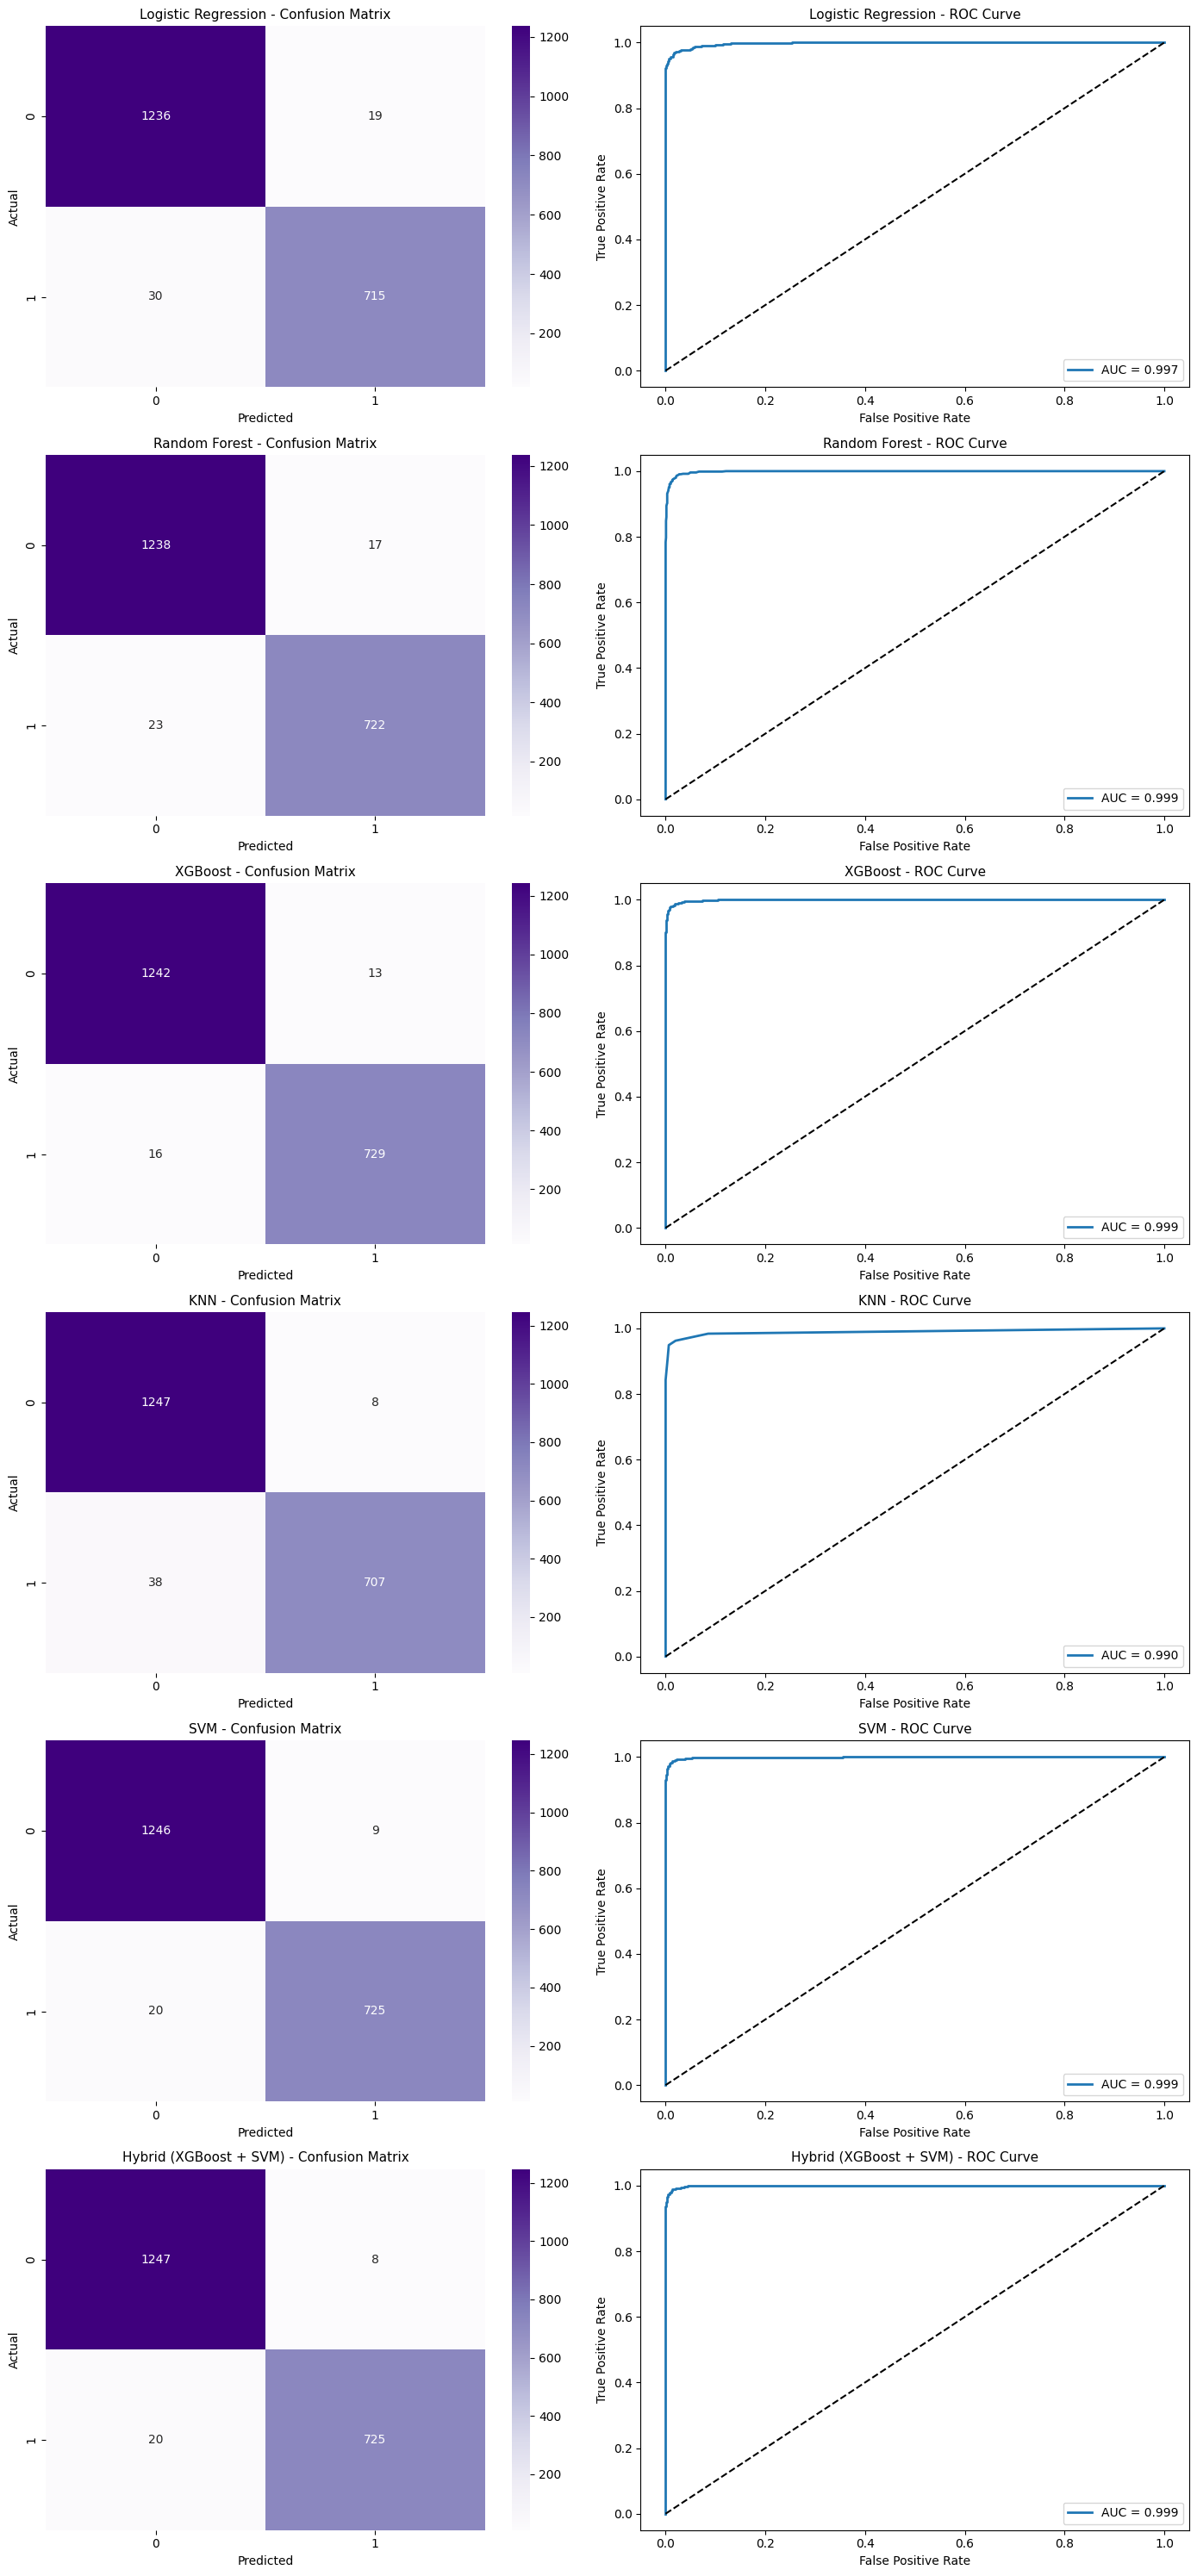

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np

# Combine all models + hybrid
all_models = dict(models)  # existing models
all_models["Hybrid (XGBoost + SVM)"] = hybrid_model  # add hybrid

# Adjust subplot grid for 6 models
fig, axes = plt.subplots(6, 2, figsize=(14, 30))

for i, (name, model) in enumerate(all_models.items()):
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", ax=axes[i,0])
    axes[i,0].set_title(f"{name} - Confusion Matrix", fontsize=11)
    axes[i,0].set_xlabel("Predicted", fontsize=10)
    axes[i,0].set_ylabel("Actual", fontsize=10)

    # --- ROC Curve ---
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        axes[i,1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
        axes[i,1].plot([0,1], [0,1], 'k--')
        axes[i,1].legend(loc="lower right")
        axes[i,1].set_title(f"{name} - ROC Curve", fontsize=11)
        axes[i,1].set_xlabel("False Positive Rate", fontsize=10)
        axes[i,1].set_ylabel("True Positive Rate", fontsize=10)
    else:
        axes[i,1].text(0.5, 0.5, "No ROC available", ha="center", va="center")
        axes[i,1].set_title(f"{name} - ROC Curve", fontsize=11)

plt.tight_layout()
plt.show()


Check training vs test performance

In [ ]:
# ✅ Check training vs test performance (including Hybrid)
train_test_results = []

# Combine existing models with hybrid model
all_models = dict(models)
all_models["Hybrid (XGBoost + SVM)"] = hybrid_model

# Loop through all models
for name, model in all_models.items():
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    train_test_results.append({
        "Model": name,
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Gap (Train-Test)": round(train_acc - test_acc, 4)
    })

# Convert to DataFrame and sort by gap
train_test_df = pd.DataFrame(train_test_results).sort_values(by="Gap (Train-Test)", ascending=False)
print("\n=== Train vs Test Accuracy Comparison ===\n")
print(train_test_df)



=== Train vs Test Accuracy Comparison ===

                    Model  Train Accuracy  Test Accuracy  Gap (Train-Test)
1           Random Forest          1.0000         0.9800            0.0200
2                 XGBoost          1.0000         0.9855            0.0145
5  Hybrid (XGBoost + SVM)          0.9916         0.9860            0.0056
3                     KNN          0.9818         0.9770            0.0048
0     Logistic Regression          0.9769         0.9755            0.0014
4                     SVM          0.9855         0.9855            0.0000


Model comparision

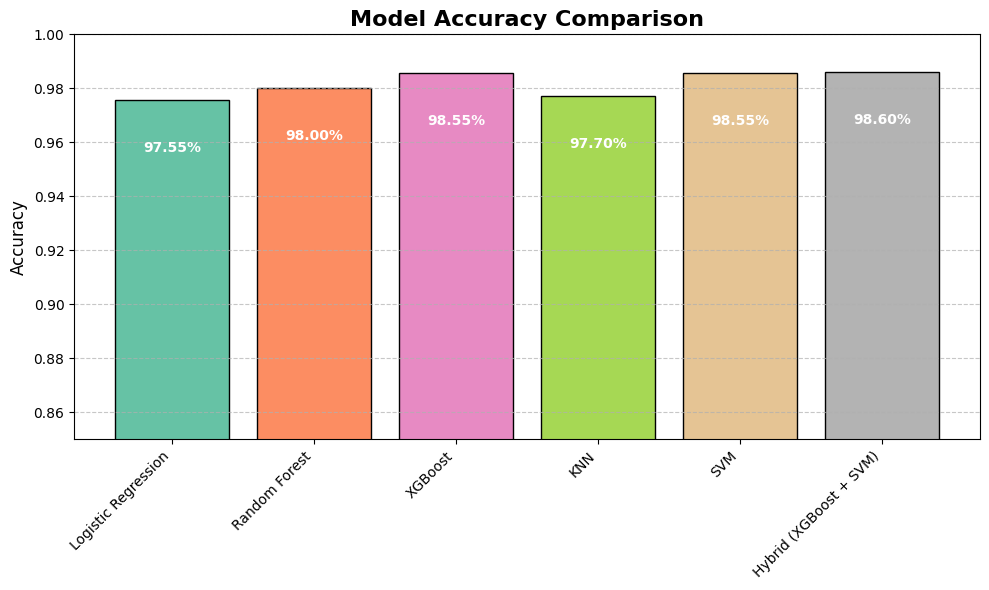

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Prepare results DataFrame for bar chart
# Assuming you already have `all_models` and X_test, y_test
accuracy_list = []

for name, model in all_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_list.append({"Model": name, "Accuracy": acc})

results_df = pd.DataFrame(accuracy_list)

# Assign unique colors for each model
colors = plt.cm.Set2(np.linspace(0, 1, len(results_df)))

# Plot bar chart
plt.figure(figsize=(10,6))
bars = plt.bar(results_df["Model"], results_df["Accuracy"], color=colors, edgecolor="black")

# Add accuracy values inside bars (in %)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height - 0.015,
             f"{height*100:.2f}%", ha="center", va="top", fontsize=10, fontweight="bold", color="white")

plt.title("Model Accuracy Comparison", fontsize=16, fontweight="bold")
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0.85, 1.0)  # adjust to zoom in since accuracies are high
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


feature importance

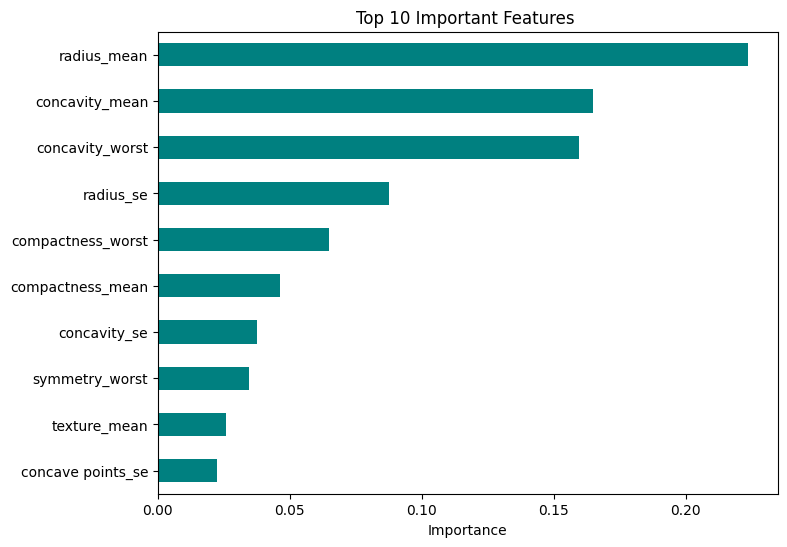

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature importance for Random Forest
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(10).plot(kind='barh', color='teal')
plt.title("Top 10 Important Features ")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()


Predict New Data (Final Step for Classification Project)

In [ ]:
# Step: Predict for New / User-Entered Data
import numpy as np
import pandas as pd

# --- Get user input interactively ---
print("Enter the values for the following features:")

# Create a dictionary to store user input
user_input = {}
for col in X.columns:
    val = float(input(f"Enter {col}: "))
    user_input[col] = [val]

# Convert to DataFrame
new_data = pd.DataFrame(user_input)

# ✅ Match feature order and scale using same scaler
new_data_scaled = scaler.transform(new_data)

# ✅ Predict with the best model (e.g., XGBoost)
best_model = models["XGBoost"]
prediction = best_model.predict(new_data_scaled)[0]

# ✅ Convert numeric output to human-readable result
result = "Malignant" if prediction == 1 else "Benign"

print("\n🔍 Predicted Class:", result)

Enter the values for the following features:
Enter radius_mean: 14
Enter texture_mean: 13
Enter smoothness_mean: 0.03
Enter compactness_mean: 0.005
Enter concavity_mean: 0.25
Enter symmetry_mean: 0.003
Enter fractal_dimension_mean: 0.30
Enter radius_se: 1.2
Enter texture_se: 2.4
Enter smoothness_se: 0.03
Enter compactness_se: 0.002
Enter concavity_se: 0.030
Enter concave points_se: 0.15
Enter symmetry_se: 0.3
Enter fractal_dimension_se: 0.006
Enter smoothness_worst: 0.45
Enter compactness_worst: 0.25
Enter concavity_worst: 0.0003
Enter symmetry_worst: 0.30
Enter fractal_dimension_worst: 0.01

🔍 Predicted Class: Malignant
